# Резонансная кривая при нелинейном взаимодействии пучка и частицы

## Условие задачи

Требуется качественно построить ожидаемую резонансную кривую в предположении, что нелинейность колебаний возникает из-за нелинейной зависимости силы взаимодействия пучка и частицы от координаты.
Используется одномерная зависимость сдвига частоты от амплитуды $\Delta \nu_b(a)$.

## Метод усреднённого гамильтониана

Резонансная кривая строится методом усреднения, стандартным для анализа резонансов в физике ускорителей.
Рассматривается движение частицы под действием нелинейной силы пучка и внешней возмущающей силы на частоте $\nu_{dr}$.
В переменных действие–угол $(J, \psi)$ гамильтониан имеет вид
$$ H(J, \psi, \theta) = H_0(J) + \epsilon V(J, \psi, \theta), $$
где $H_0(J)$ описывает свободные нелинейные колебания с зависящей от амплитуды частотой $\nu(J) = \partial H_0 / \partial J$, а возмущение $V \propto x F_{drive}(\theta) \propto \sqrt{2J} \cos\psi \cos(\nu_{dr} \theta)$.

Произведение косинусов даёт слагаемые с фазами $\psi - \nu_{dr}\theta$ и $\psi + \nu_{dr}\theta$.
Вблизи резонанса $\nu(J) \approx \nu_{dr}$ первая фаза меняется медленно, а вторая быстро, и после усреднения по быстрым осцилляциям остаётся только резонансный член:
$$ H \approx H_0(J) + \epsilon_{eff} \sqrt{2J} \cos(\psi - \nu_{dr} \theta). $$
Каноническое преобразование к медленной фазе $\phi = \psi - \nu_{dr}\theta$ даёт гамильтониан во вращающейся системе отсчёта
$$ K(J, \phi) = H_0(J) - \nu_{dr} J + \epsilon_{eff} \sqrt{2J} \cos\phi, $$
в котором первые два слагаемых описывают расстройку, а третье — возбуждение.
Производная расстройки по действию равна разности частот, $\partial (H_0 - \nu_{dr} J) / \partial J = \nu(J) - \nu_{dr}$.

Установившаяся амплитуда колебаний соответствует неподвижной точке в фазовом пространстве $(J, \phi)$, в которой $\dot{J} = 0$ и $\dot{\phi} = 0$.
Из уравнения для действия
$$ \dot{J} = -\frac{\partial K}{\partial \phi} = \epsilon_{eff} \sqrt{2J} \sin\phi = 0 $$
следует, что фаза равна $0$ или $\pi$: частица колеблется в фазе с силой либо в противофазе.
Уравнение для фазы
$$ \dot{\phi} = \frac{\partial K}{\partial J} = \nu(J) - \nu_{dr} \pm \frac{\epsilon_{eff}}{\sqrt{2J}} = 0, $$
где знак определяется значением $\cos\phi = \pm 1$, после перехода от действия к амплитуде $A \sim \sqrt{2J}$ даёт уравнение баланса частот
$$ \nu_{dr} = \nu(A) \pm \frac{C}{A}. $$
Здесь $\nu(A)$ — скелетная кривая, собственная частота колебаний как функция амплитуды, а слагаемое $\pm C/A$ описывает ширину резонанса, создаваемую внешней силой.
С ростом амплитуды член $C/A$ убывает, и влияние внешней силы на частоту ослабевает.
Это уравнение используется для построения точных границ резонанса.

Сдвиг частоты как функция амплитуды для одномерных колебаний в поле круглого гауссова пучка равен
$$ \frac{\Delta \nu(A)}{\xi} = \frac{2}{z} \left( 1 - e^{-z/2} I_0\!\left(\frac{z}{2}\right) \right), \qquad z = \frac{A^2}{2\sigma^2}, $$
где $\xi$ — сдвиг частоты при малых амплитудах, а $I_0$ — модифицированная функция Бесселя.
Форм-фактор убывает от единицы при $A = 0$ до нуля при $A \gg \sigma$.
Для взаимодействия зарядов одного знака сила отталкивающая, $\xi < 0$, и скелетная кривая наклонена в сторону больших частот, как у пружины с растущей жёсткостью.
Резонансные ветви $\nu(A) \pm C/A$ образуют наклонённый в ту же сторону язык резонанса.

## Численный расчёт

Построены зависимость сдвига частоты от амплитуды и резонансные кривые для трёх значений силы возбуждения при $\xi = -0.05$ и $\nu_0 = 0.31$.

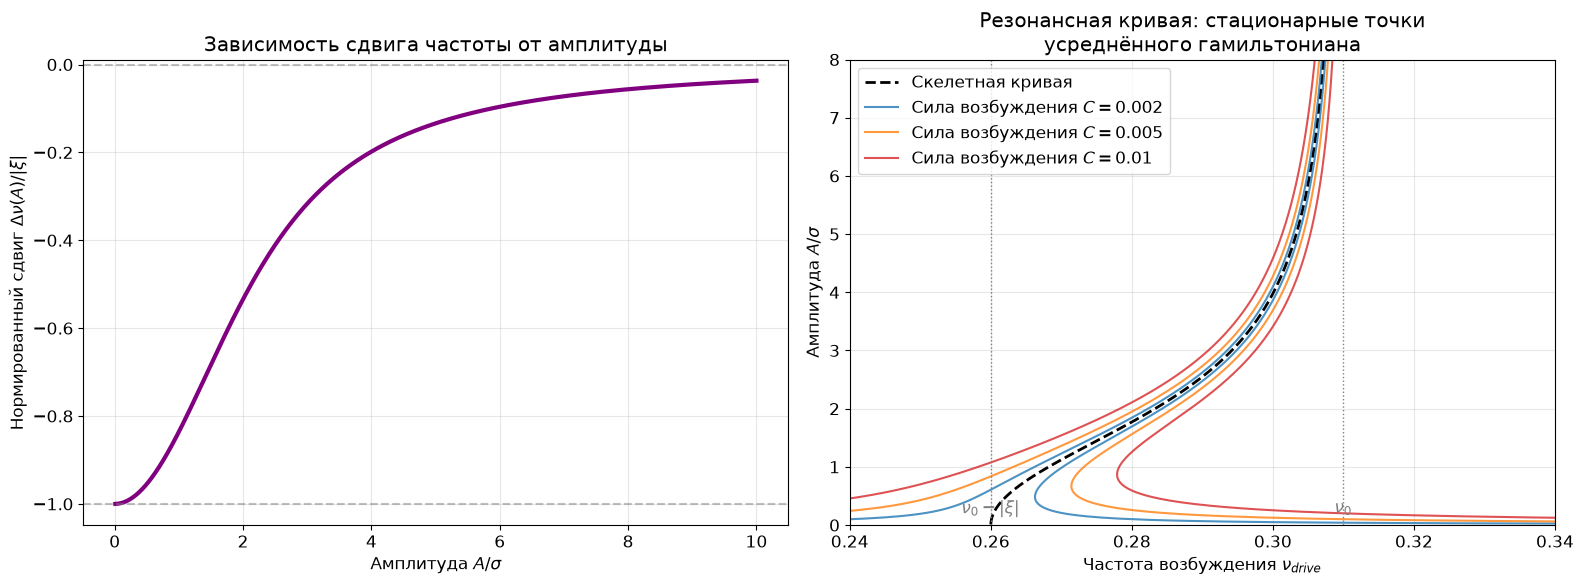

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import i0

# Настройка графиков
%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

def beam_beam_tune_shift_1d(amplitude, sigma, xi):
    """
    Вычисляет сдвиг частоты для 1D гауссова пучка.
    Delta_nu / xi = (2/J) * (1 - exp(-J/2)*I0(J/2))
    где J = (amplitude / sigma)^2 / 2
    """
    amp = np.array(amplitude)
    # Избегаем деления на ноль в J
    amp_safe = np.where(amp < 1e-6, 1e-6, amp)
    J = (amp_safe**2) / (2 * sigma**2)
    
    with np.errstate(divide='ignore', invalid='ignore'):
        factor = (2.0 / J) * (1.0 - np.exp(-J/2.0) * i0(J/2.0))
    
    # В нуле фактор равен 1
    factor = np.where(amp < 1e-6, 1.0, factor)
    
    return xi * factor

# Параметры
sigma = 1.0
xi = -0.05 # Отрицательный сдвиг (дефокусировка)
nu_0 = 0.31

# Амплитуды
amplitudes = np.linspace(0.01, 10*sigma, 1000) # Начинаем не с 0, чтобы не делить на 0 в C/A

# 1. Скелетная кривая (Backbone)
nu_backbone = nu_0 + beam_beam_tune_shift_1d(amplitudes, sigma, xi)

# Визуализация
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# --- График 1: Сдвиг частоты ---
ax1.plot(amplitudes/sigma, (nu_backbone - nu_0)/abs(xi), linewidth=3, color='purple')
ax1.set_title('Зависимость сдвига частоты от амплитуды')
ax1.set_xlabel(r'Амплитуда $A / \sigma$')
ax1.set_ylabel(r'Нормированный сдвиг $\Delta \nu(A) / |\xi|$')
ax1.grid(True, alpha=0.3)
ax1.axhline(-1, color='gray', linestyle='--', alpha=0.5)
ax1.axhline(0, color='gray', linestyle='--', alpha=0.5)

# --- График 2: Точная резонансная кривая ---
ax2.plot(nu_backbone, amplitudes/sigma, 'k--', linewidth=2, label='Скелетная кривая')

# Силы возбуждения (коэффициент C в формуле C/A)
# C пропорционально силе F. Подберем значения для наглядности.
C_values = [0.002, 0.005, 0.010] 
colors = ['tab:blue', 'tab:orange', 'tab:red']

for i, C in enumerate(C_values):
    # Уравнение границ резонанса: nu_dr = nu(A) +/- C/A
    # Это точное решение для стационарных точек усредненного гамильтониана
    
    term = C / (amplitudes/sigma) # C/A
    
    nu_left = nu_backbone - term
    nu_right = nu_backbone + term
    
    label = f'Сила возбуждения $C={C}$'
    
    # Рисуем левую и правую ветви
    # Чтобы график выглядел как единая кривая, можно соединить их
    # Но физически это границы гистерезиса
    ax2.plot(nu_left, amplitudes/sigma, color=colors[i], alpha=0.8, label=label)
    ax2.plot(nu_right, amplitudes/sigma, color=colors[i], alpha=0.8)
    
    # Закрасим область резонанса (где возможны скачки)
    # ax2.fill_betweenx(amplitudes/sigma, nu_left, nu_right, color=colors[i], alpha=0.1)

ax2.set_title('Резонансная кривая: стационарные точки\nусреднённого гамильтониана')
ax2.set_xlabel('Частота возбуждения $\\nu_{drive}$')
ax2.set_ylabel(r'Амплитуда $A / \sigma$')

# Настройка пределов
x_min = nu_0 + xi - 0.02
x_max = nu_0 + 0.03
ax2.set_xlim(x_min, x_max)
ax2.set_ylim(0, 8)

# Линии
ax2.axvline(nu_0, color='gray', linestyle=':', linewidth=1)
ax2.text(nu_0, 0.2, '$\\nu_0$', ha='center', color='gray')
ax2.axvline(nu_0 + xi, color='gray', linestyle=':', linewidth=1)
ax2.text(nu_0 + xi, 0.2, '$\\nu_0 - |\\xi|$', ha='center', color='gray')

ax2.legend(loc='upper left')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Сравнение с задачей о четырёхпучковой схеме

В задаче о скомпенсированной схеме сдвиг частоты вычислялся через производную силы, тогда как здесь используется усреднение профиля силы по траектории.
Различие связано с разными режимами колебаний.

В скомпенсированной схеме рассматривается частица, совершающая малые колебания около центра $x \approx 0$.
Сила раскладывается в ряд $F(x) \approx F(0) + F'(0) x$, уравнение движения принимает вид $\ddot{x} + [-F'(0)] x = 0$, и сдвиг частоты определяется локальным градиентом силы в точке равновесия.

В настоящей задаче амплитуда $A$ велика, частица уходит далеко от центра, где линейное приближение не работает, и проходит весь профиль силы.
Эффективная частота определяется усреднением силы по траектории:
$$ \Delta \nu(A) \propto \frac{1}{A} \oint F(x(t)) \cos\psi \, dt, $$
так что существенна форма силы $F(x)$, а не только её наклон в центре.

Различаются и аргументы построенных зависимостей.
В скомпенсированной схеме аргументом служит смещение пучков $a$: при $a = 0$ пучки компенсируют друг друга, градиент и сдвиг равны нулю, а с ростом $a$ компенсация нарушается и сдвиг растёт от нуля.
В настоящей задаче аргументом служит амплитуда частицы $A$: при $A = 0$ частица находится в центре, где плотность заряда и фокусировка максимальны, а с ростом $A$ частица большую часть времени проводит на периферии, где пучка почти нет, и фокусировка падает от максимума.

## Итоги

Резонансная кривая нелинейного осциллятора определяется уравнением $\nu_{dr} = \nu(A) \pm C/A$, следующим из условия неподвижной точки усреднённого гамильтониана.
Для отталкивающего взаимодействия скелетная кривая и язык резонанса наклонены в сторону больших частот, ширина языка растёт с силой возбуждения и убывает с амплитудой.